In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')
data_path = "/content/drive/My Drive"

Mounted at /content/drive


In [2]:
!ls "/content/drive/My Drive/ECG_dataset/preprocessed_data"

sym_all.csv  sym_all.pkl  X_all_normalized.npy


In [3]:
import numpy as np
import os
import pickle
from collections import Counter
from sklearn.preprocessing import LabelEncoder
import gc

# === Load Original Preprocessed Data ===
X_all_normalized = np.load('/content/drive/My Drive/ECG_dataset/preprocessed_data/X_all_normalized.npy')
with open('/content/drive/My Drive/ECG_dataset/preprocessed_data/sym_all.pkl', 'rb') as f:
    sym_all = pickle.load(f)

# === Label Encoding ===
ECG_classes = ['N', 'L', 'R', 'V', '/', 'A', 'f', 'F', 'j', 'a', 'E', 'J', 'e', 'S']
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(ECG_classes)
Y_all = label_encoder.transform(sym_all)

# === Undersample Class 0 and 1 ===
target_samples = 8000
mask_0 = (Y_all == 0)
mask_1 = (Y_all == 1)

X0 = X_all_normalized[mask_0]
Y0 = Y_all[mask_0]
X1 = X_all_normalized[mask_1]
Y1 = Y_all[mask_1]

idx0 = np.random.choice(len(X0), target_samples, replace=False)
idx1 = np.random.choice(len(X1), target_samples, replace=False)

X0_down = X0[idx0]
Y0_down = Y0[idx0]
X1_down = X1[idx1]
Y1_down = Y1[idx1]

# Combine class 0 & 1
X_all_combined = [X0_down, X1_down]
Y_all_combined = [Y0_down, Y1_down]

# Cleanup
del X0, Y0, X1, Y1, X0_down, Y0_down, X1_down, Y1_down, idx0, idx1
gc.collect()

# === Load Resampled Classes 2–12 ===
base_path = '/content/drive/My Drive/ECG_dataset/SMOTEresampling'

for class_id in range(2, 13):
    folder = f'resampled_class_{class_id}'
    x_path = os.path.join(base_path, folder, f'X_generate_{class_id}.npy')
    y_path = os.path.join(base_path, folder, f'Y_generate_{class_id}.npy')

    x = np.load(x_path)
    y = np.load(y_path)

    X_all_combined.append(x)
    Y_all_combined.append(y)

# === Manually Oversample Class 13 ===
class_13 = 13
mask_13 = (Y_all == class_13)
X13 = X_all_normalized[mask_13]
Y13 = Y_all[mask_13]

X13_oversampled = np.tile(X13, (8000 // len(X13), 1))
Y13_oversampled = np.tile(Y13, (8000 // len(Y13),))
remaining = 8000 - len(X13_oversampled)
if remaining > 0:
    idx = np.random.choice(len(X13), remaining)
    X13_oversampled = np.vstack([X13_oversampled, X13[idx]])
    Y13_oversampled = np.hstack([Y13_oversampled, Y13[idx]])

X_all_combined.append(X13_oversampled)
Y_all_combined.append(Y13_oversampled)

# Cleanup
del X13, Y13, X13_oversampled, Y13_oversampled, mask_13, Y_all, sym_all, X_all_normalized
gc.collect()

# === Final Combine ===
X_final = np.vstack(X_all_combined)
Y_final = np.hstack(Y_all_combined)

print("✅ Final combined shape:", X_final.shape, Y_final.shape)
print("✅ Final class distribution:", Counter(Y_final))


✅ Final combined shape: (112000, 2160) (112000,)
✅ Final class distribution: Counter({np.int64(0): 8000, np.int64(1): 8000, np.int64(2): 8000, np.int64(3): 8000, np.int64(4): 8000, np.int64(5): 8000, np.int64(6): 8000, np.int64(7): 8000, np.int64(8): 8000, np.int64(9): 8000, np.int64(10): 8000, np.int64(11): 8000, np.int64(12): 8000, np.int64(13): 8000})


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import gc
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K

# === Final Data ===
num_classes = 14
X_final_cnn = X_final.reshape((X_final.shape[0], X_final.shape[1], 1))
Y_final_cat = to_categorical(Y_final, num_classes=num_classes)

# === Stratified 5-Fold CV ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_per_fold = []
precision_per_fold = []
recall_per_fold = []
f1_per_fold = []
time_per_fold = []
all_histories = []
fold_no = 1


--- Fold 1 ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - accuracy: 0.4328 - loss: 1.6948 - val_accuracy: 0.9361 - val_loss: 0.2116
Epoch 2/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 79s 74ms/step - accuracy: 0.8610 - loss: 0.4164 - val_accuracy: 0.9663 - val_loss: 0.1142
Epoch 3/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 81s 73ms/step - accuracy: 0.9027 - loss: 0.2887 - val_accuracy: 0.9758 - val_loss: 0.0815
Epoch 4/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 82s 72ms/step - accuracy: 0.9207 - loss: 0.2316 - val_accuracy: 0.9782 - val_loss: 0.0777
Epoch 5/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.9328 - loss: 0.1947 - val_accuracy: 0.9832 - val_loss: 0.0577
Epoch 6/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 83s 74ms/step - accuracy: 0.9404 - loss: 0.1703 - val_accuracy: 0.9854 - val_loss: 0.0533
Epoch 7/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 82s 73ms/step - accuracy: 0.9426 - loss: 0.1635 - val_accuracy: 0.9856 - val_loss: 0.0505
Epoch 8/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 83s 74ms/step - accuracy: 0.9491 - loss: 0.1468 - 

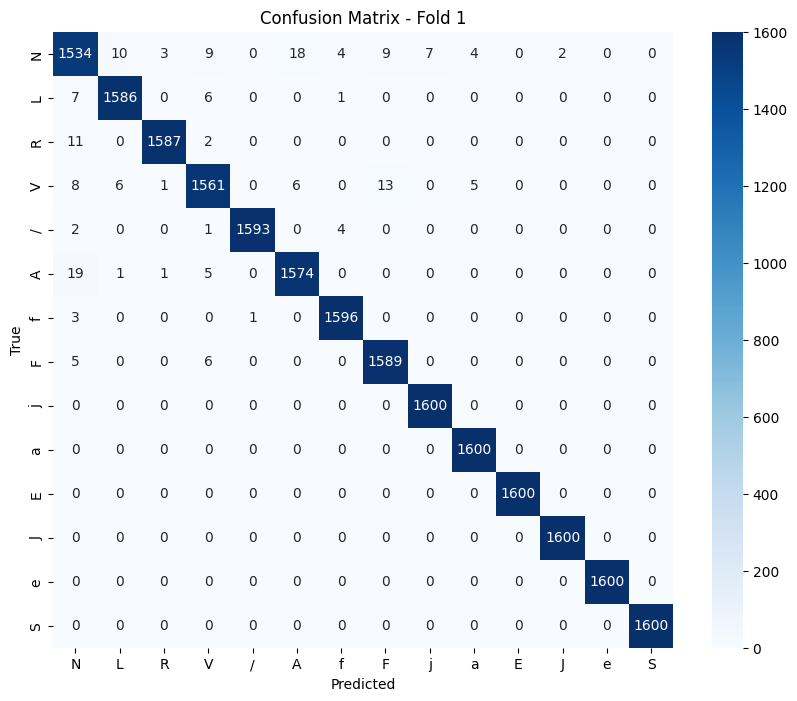


--- Fold 2 ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 55s 74ms/step - accuracy: 0.4229 - loss: 1.7291 - val_accuracy: 0.9438 - val_loss: 0.1884
Epoch 2/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 80s 74ms/step - accuracy: 0.8785 - loss: 0.3751 - val_accuracy: 0.9607 - val_loss: 0.1226
Epoch 3/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.9119 - loss: 0.2684 - val_accuracy: 0.9751 - val_loss: 0.0841
Epoch 4/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 83s 75ms/step - accuracy: 0.9256 - loss: 0.2233 - val_accuracy: 0.9779 - val_loss: 0.0779
Epoch 5/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.9377 - loss: 0.1855 - val_accuracy: 0.9820 - val_loss: 0.0603
Epoch 6/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 82s 74ms/step - accuracy: 0.9449 - loss: 0.1633 - val_accuracy: 0.9835 - val_loss: 0.0534
Epoch 7/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 50s 72ms/step - accuracy: 0.9507 - loss: 0.1477 - val_accuracy: 0.9855 - val_loss: 0.0514
Epoch 8/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 83s 73ms/step - accuracy: 0.9554 - loss: 0.1353 - 

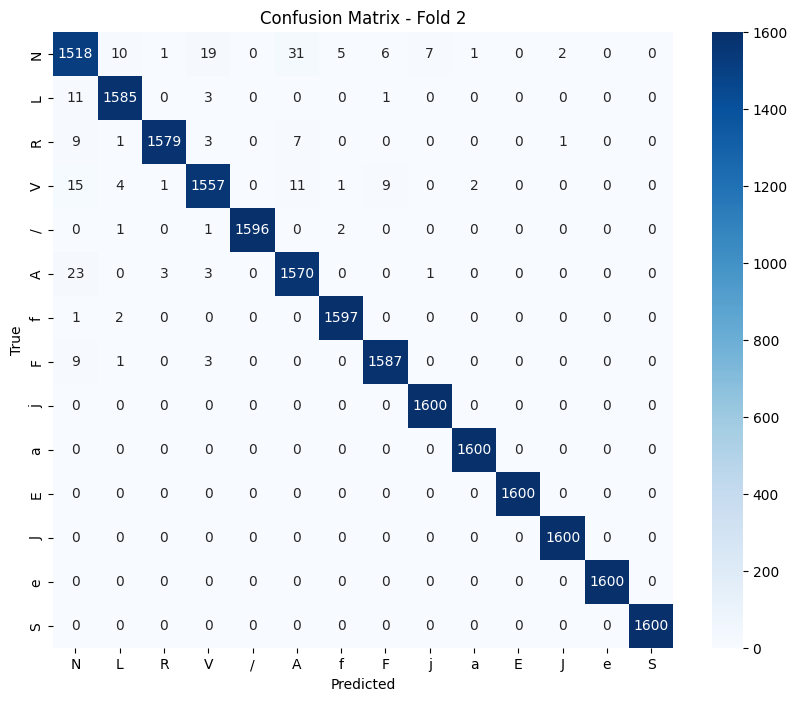


--- Fold 3 ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 56s 75ms/step - accuracy: 0.3095 - loss: 2.0425 - val_accuracy: 0.9230 - val_loss: 0.2621
Epoch 2/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 51s 72ms/step - accuracy: 0.8537 - loss: 0.4510 - val_accuracy: 0.9566 - val_loss: 0.1414
Epoch 3/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 83s 73ms/step - accuracy: 0.8940 - loss: 0.3189 - val_accuracy: 0.9669 - val_loss: 0.1122
Epoch 4/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 50s 72ms/step - accuracy: 0.9141 - loss: 0.2526 - val_accuracy: 0.9720 - val_loss: 0.0921
Epoch 5/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 50s 72ms/step - accuracy: 0.9280 - loss: 0.2168 - val_accuracy: 0.9758 - val_loss: 0.0794
Epoch 6/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 82s 73ms/step - accuracy: 0.9353 - loss: 0.1908 - val_accuracy: 0.9787 - val_loss: 0.0720
Epoch 7/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 83s 74ms/step - accuracy: 0.9405 - loss: 0.1764 - val_accuracy: 0.9807 - val_loss: 0.0659
Epoch 8/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 81s 74ms/step - accuracy: 0.9451 - loss: 0.1619 - 

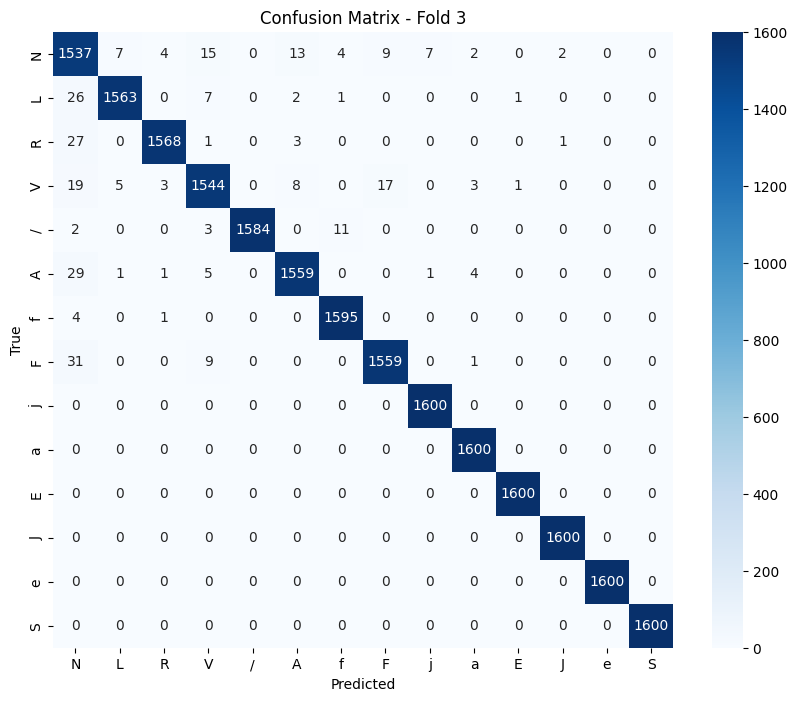


--- Fold 4 ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 55s 74ms/step - accuracy: 0.5079 - loss: 1.5077 - val_accuracy: 0.9404 - val_loss: 0.1815
Epoch 2/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.9152 - loss: 0.2716 - val_accuracy: 0.9698 - val_loss: 0.1075
Epoch 3/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 83s 75ms/step - accuracy: 0.9378 - loss: 0.1935 - val_accuracy: 0.9787 - val_loss: 0.0758
Epoch 4/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 81s 74ms/step - accuracy: 0.9556 - loss: 0.1377 - val_accuracy: 0.9856 - val_loss: 0.0535
Epoch 5/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.9580 - loss: 0.1291 - val_accuracy: 0.9866 - val_loss: 0.0463
Epoch 6/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 83s 74ms/step - accuracy: 0.9689 - loss: 0.0957 - val_accuracy: 0.9879 - val_loss: 0.0453
Epoch 7/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 82s 75ms/step - accuracy: 0.9718 - loss: 0.0856 - val_accuracy: 0.9888 - val_loss: 0.0378
Epoch 8/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 52s 75ms/step - accuracy: 0.9741 - loss: 0.0796 - 

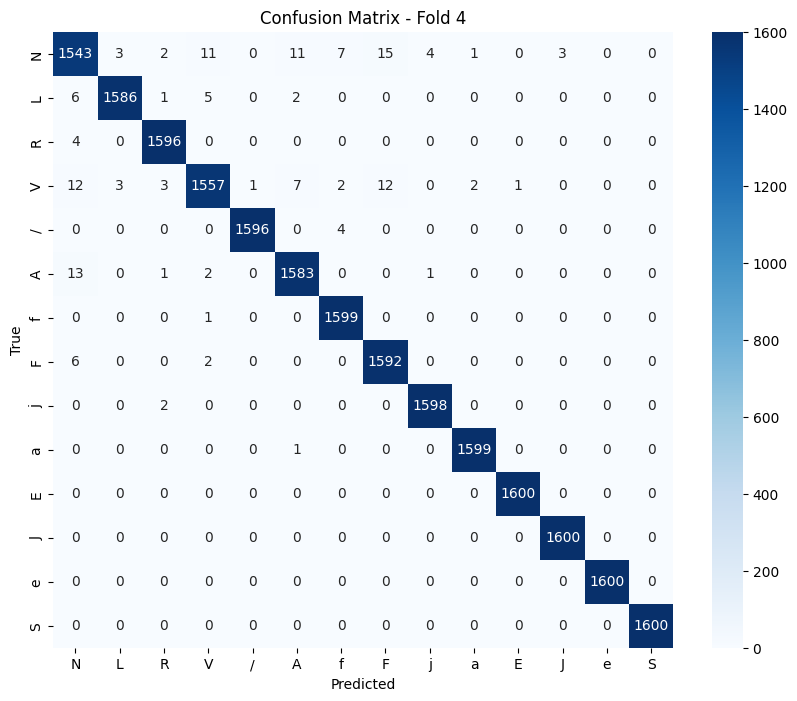


--- Fold 5 ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 55s 73ms/step - accuracy: 0.3417 - loss: 1.9357 - val_accuracy: 0.9226 - val_loss: 0.2560
Epoch 2/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.8056 - loss: 0.5636 - val_accuracy: 0.9465 - val_loss: 0.1880
Epoch 3/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 82s 73ms/step - accuracy: 0.8488 - loss: 0.4370 - val_accuracy: 0.9633 - val_loss: 0.1221
Epoch 4/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 81s 72ms/step - accuracy: 0.8728 - loss: 0.3684 - val_accuracy: 0.9707 - val_loss: 0.0972
Epoch 5/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 83s 73ms/step - accuracy: 0.8879 - loss: 0.3253 - val_accuracy: 0.9729 - val_loss: 0.0907
Epoch 6/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 81s 72ms/step - accuracy: 0.8973 - loss: 0.3010 - val_accuracy: 0.9787 - val_loss: 0.0741
Epoch 7/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 83s 73ms/step - accuracy: 0.9059 - loss: 0.2730 - val_accuracy: 0.9796 - val_loss: 0.0675
Epoch 8/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 81s 72ms/step - accuracy: 0.9166 - loss: 0.2457 - 

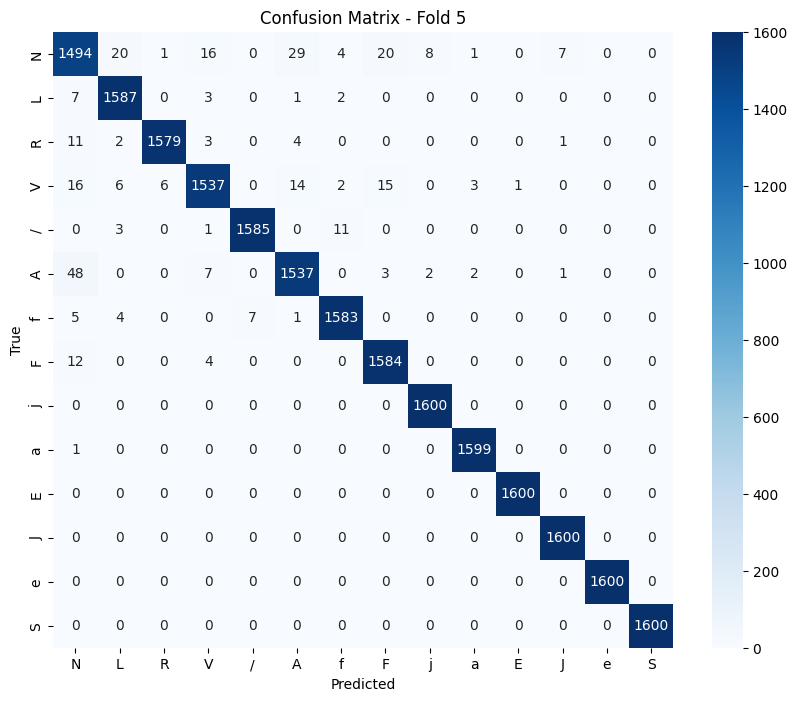


✅ Total training time for 5 folds: 5518.49 seconds


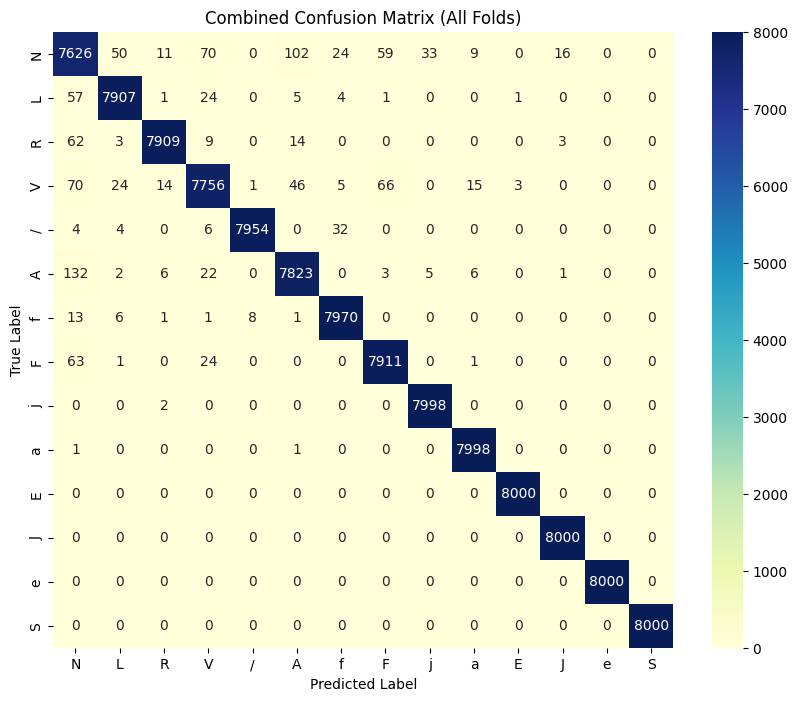

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report, accuracy_score,
                             precision_score, recall_score, f1_score, confusion_matrix)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K

# === ECG Classes ===
ECG_classes = ['N', 'L', 'R', 'V', '/', 'A', 'f', 'F', 'j', 'a', 'E', 'J', 'e', 'S']
num_classes = len(ECG_classes)

# === Prepare Final Data ===
X_final_cnn = X_final.reshape((X_final.shape[0], X_final.shape[1], 1))
Y_final_cat = to_categorical(Y_final, num_classes=num_classes)

# === Stratified 5-Fold CV ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_per_fold = []
precision_per_fold = []
recall_per_fold = []
f1_per_fold = []
time_per_fold = []
all_histories = []
all_y_true = []
all_y_pred = []
fold_no = 1

# Start total timer
total_start_time = time.time()

for train_idx, val_idx in skf.split(X_final_cnn, Y_final):
    print(f"\n--- Fold {fold_no} ---")

    X_train, X_val = X_final_cnn[train_idx], X_final_cnn[val_idx]
    y_train_cat, y_val_cat = Y_final_cat[train_idx], Y_final_cat[val_idx]
    y_val_true = Y_final[val_idx]

    # Define model
    model = Sequential([
        Conv1D(filters=64, kernel_size=7, activation='relu', input_shape=(X_train.shape[1], 1)),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=128, kernel_size=5, activation='relu'),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=256, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Start fold timer
    start_time = time.time()

    # Train model
    history = model.fit(
        X_train, y_train_cat,
        epochs=15,
        batch_size=128,
        validation_data=(X_val, y_val_cat),
        verbose=1
    )

    # End fold timer
    end_time = time.time()
    fold_time = end_time - start_time
    time_per_fold.append(fold_time)
    all_histories.append(history.history)

    # Evaluate
    y_pred = np.argmax(model.predict(X_val), axis=1)

    acc = accuracy_score(y_val_true, y_pred)
    prec = precision_score(y_val_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_val_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_val_true, y_pred, average='macro', zero_division=0)

    acc_per_fold.append(acc)
    precision_per_fold.append(prec)
    recall_per_fold.append(rec)
    f1_per_fold.append(f1)

    all_y_true.append(y_val_true)
    all_y_pred.append(y_pred)

    print(f"Fold {fold_no} Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f} | Recall: {rec:.4f} | F1-score: {f1:.4f}")
    print(f"Training time: {fold_time:.2f} seconds")
    print("Classification Report:")
    print(classification_report(y_val_true, y_pred, target_names=ECG_classes))

    # Confusion matrix per fold
    cm = confusion_matrix(y_val_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ECG_classes, yticklabels=ECG_classes)
    plt.title(f'Confusion Matrix - Fold {fold_no}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Cleanup
    del model
    K.clear_session()
    gc.collect()
    fold_no += 1

# End total timer
total_end_time = time.time()
total_duration = total_end_time - total_start_time

print(f"\n✅ Total training time for 5 folds: {total_duration:.2f} seconds")

# === Combined Confusion Matrix ===
combined_true = np.concatenate(all_y_true)
combined_pred = np.concatenate(all_y_pred)

cm_total = confusion_matrix(combined_true, combined_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_total, annot=True, fmt='d', cmap='YlGnBu', xticklabels=ECG_classes, yticklabels=ECG_classes)
plt.title('Combined Confusion Matrix (All Folds)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


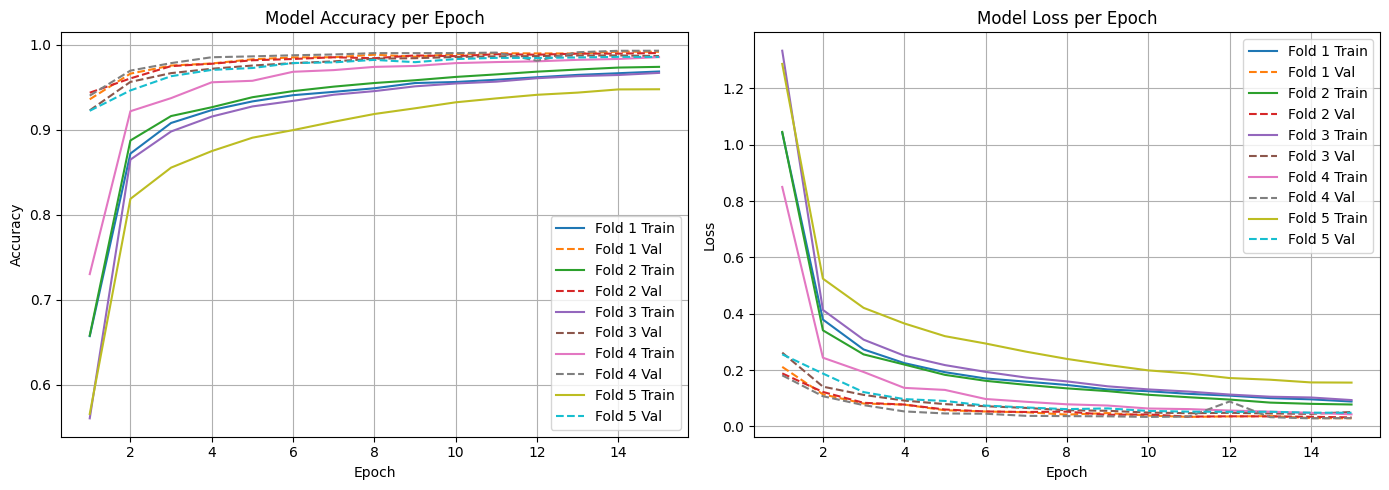

In [6]:
# === Plot Accuracy and Loss Curves ===
epochs = range(1, 16)

plt.figure(figsize=(14, 5))

# Accuracy Curves
plt.subplot(1, 2, 1)
for i, hist in enumerate(all_histories):
    plt.plot(epochs, hist['accuracy'], label=f'Fold {i+1} Train')
    plt.plot(epochs, hist['val_accuracy'], linestyle='--', label=f'Fold {i+1} Val')
plt.title('Model Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Curves
plt.subplot(1, 2, 2)
for i, hist in enumerate(all_histories):
    plt.plot(epochs, hist['loss'], label=f'Fold {i+1} Train')
    plt.plot(epochs, hist['val_loss'], linestyle='--', label=f'Fold {i+1} Val')
plt.title('Model Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

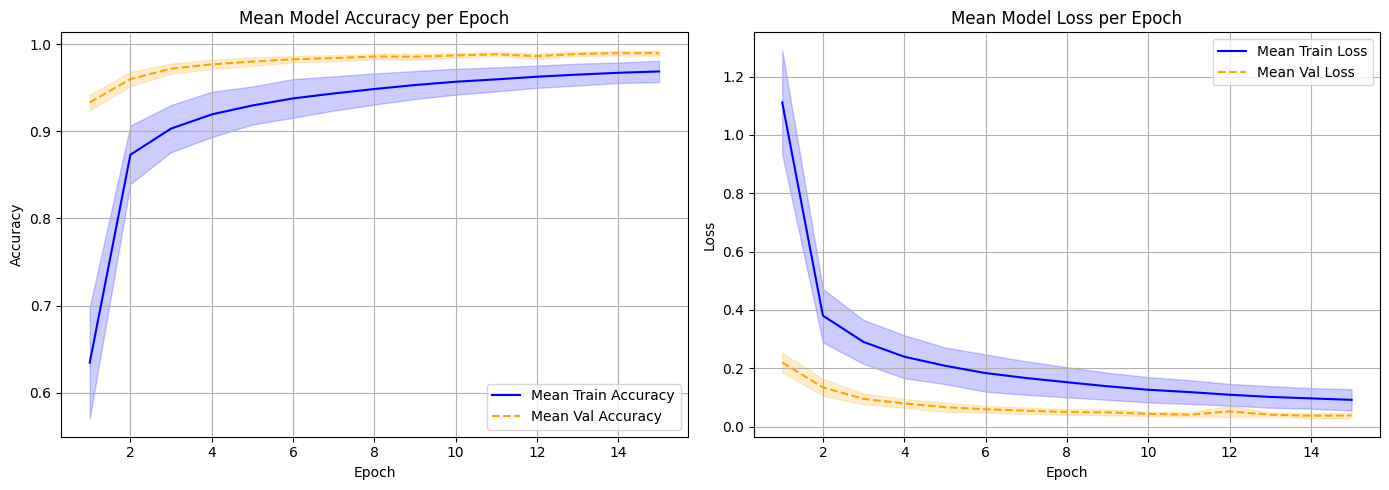

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming all_histories is a list of dicts with keys: 'accuracy', 'val_accuracy', 'loss', 'val_loss'
epochs = range(1, 16)

# Convert to arrays for easier mean calculation
num_folds = len(all_histories)
num_epochs = len(all_histories[0]['accuracy'])

accuracy = np.array([hist['accuracy'] for hist in all_histories])
val_accuracy = np.array([hist['val_accuracy'] for hist in all_histories])
loss = np.array([hist['loss'] for hist in all_histories])
val_loss = np.array([hist['val_loss'] for hist in all_histories])

# Calculate mean and standard deviation
mean_accuracy = np.mean(accuracy, axis=0)
std_accuracy = np.std(accuracy, axis=0)
mean_val_accuracy = np.mean(val_accuracy, axis=0)
std_val_accuracy = np.std(val_accuracy, axis=0)

mean_loss = np.mean(loss, axis=0)
std_loss = np.std(loss, axis=0)
mean_val_loss = np.mean(val_loss, axis=0)
std_val_loss = np.std(val_loss, axis=0)

# === Plot ===
plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, mean_accuracy, label='Mean Train Accuracy', color='blue')
plt.fill_between(epochs, mean_accuracy - std_accuracy, mean_accuracy + std_accuracy, color='blue', alpha=0.2)
plt.plot(epochs, mean_val_accuracy, label='Mean Val Accuracy', color='orange', linestyle='--')
plt.fill_between(epochs, mean_val_accuracy - std_val_accuracy, mean_val_accuracy + std_val_accuracy, color='orange', alpha=0.2)
plt.title('Mean Model Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, mean_loss, label='Mean Train Loss', color='blue')
plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, color='blue', alpha=0.2)
plt.plot(epochs, mean_val_loss, label='Mean Val Loss', color='orange', linestyle='--')
plt.fill_between(epochs, mean_val_loss - std_val_loss, mean_val_loss + std_val_loss, color='orange', alpha=0.2)
plt.title('Mean Model Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



=== Cross-Validation Summary ===
Fold 1: Accuracy = 0.9920, Precision = 0.9919, Recall = 0.9920, F1-score = 0.9920, Time = 1110.85 sec
Fold 2: Accuracy = 0.9906, Precision = 0.9906, Recall = 0.9906, F1-score = 0.9906, Time = 1080.54 sec
Fold 3: Accuracy = 0.9870, Precision = 0.9872, Recall = 0.9870, F1-score = 0.9871, Time = 1084.74 sec
Fold 4: Accuracy = 0.9933, Precision = 0.9932, Recall = 0.9933, F1-score = 0.9932, Time = 1052.52 sec
Fold 5: Accuracy = 0.9859, Precision = 0.9859, Recall = 0.9859, F1-score = 0.9859, Time = 1145.50 sec

Average Accuracy: 0.9898
Average Precision: 0.9898
Average Recall: 0.9898
Average F1-score: 0.9898
Total Training Time: 5518.49 seconds


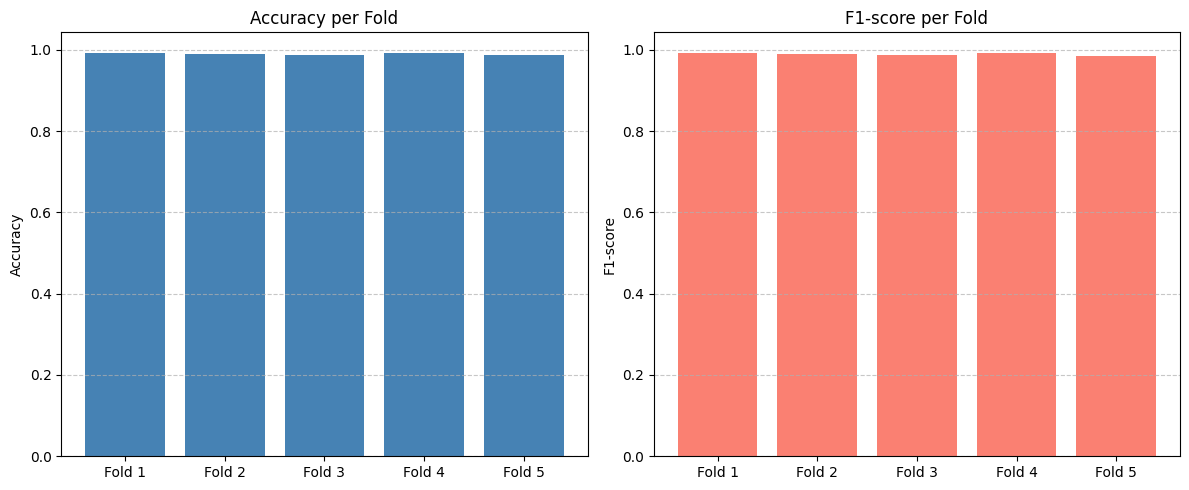

In [7]:
# === Summary ===
print("\n=== Cross-Validation Summary ===")
for i in range(5):
    print(f"Fold {i+1}: "
          f"Accuracy = {acc_per_fold[i]:.4f}, "
          f"Precision = {precision_per_fold[i]:.4f}, "
          f"Recall = {recall_per_fold[i]:.4f}, "
          f"F1-score = {f1_per_fold[i]:.4f}, "
          f"Time = {time_per_fold[i]:.2f} sec")

print(f"\nAverage Accuracy: {np.mean(acc_per_fold):.4f}")
print(f"Average Precision: {np.mean(precision_per_fold):.4f}")
print(f"Average Recall: {np.mean(recall_per_fold):.4f}")
print(f"Average F1-score: {np.mean(f1_per_fold):.4f}")
print(f"Total Training Time: {total_duration:.2f} seconds")

# === Plot Accuracy and F1-score ===
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.bar(range(1, 6), acc_per_fold, color='steelblue')
plt.xticks(range(1, 6), [f'Fold {i}' for i in range(1, 6)])
plt.ylabel('Accuracy')
plt.title('Accuracy per Fold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# F1-score
plt.subplot(1, 2, 2)
plt.bar(range(1, 6), f1_per_fold, color='salmon')
plt.xticks(range(1, 6), [f'Fold {i}' for i in range(1, 6)])
plt.ylabel('F1-score')
plt.title('F1-score per Fold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


/var/folders/vy/h0yt7lx97b5ct5kp84j7dk_40000gn/T/ipykernel_1697/1464410716.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=accuracy_percentages, palette="crest")


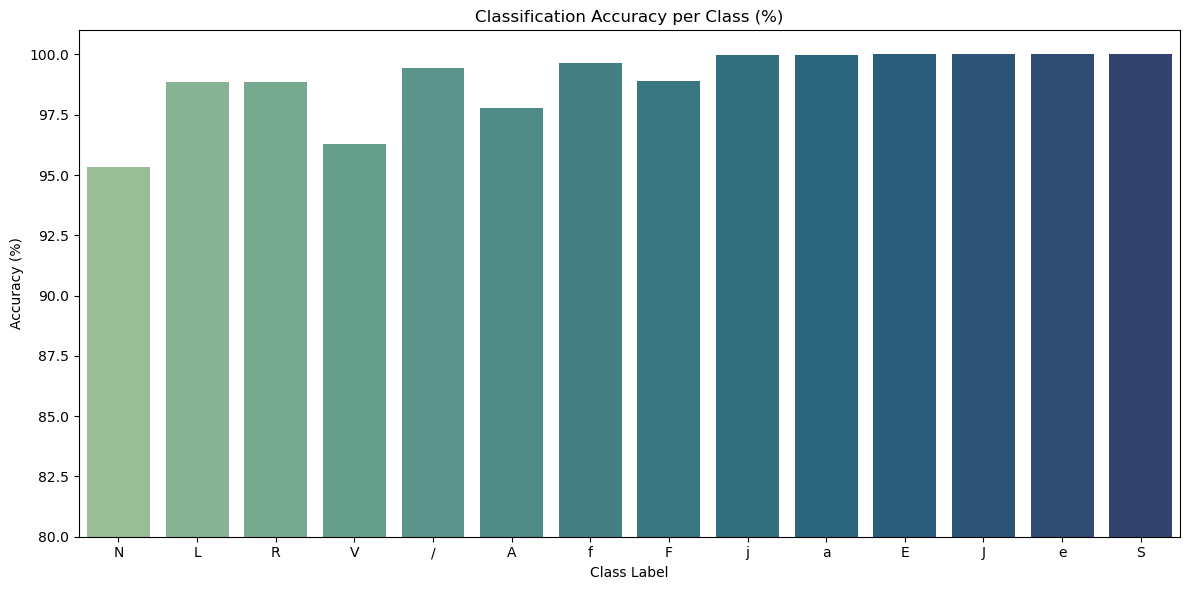

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Labels and true positive counts
labels = ['N', 'L', 'R', 'V', '/', 'A', 'f', 'F', 'j', 'a', 'E', 'J', 'e', 'S']
true_positives = [7626, 7907, 7909, 7756, 7954, 7823, 7970, 7911, 7998, 7998, 8000, 8000, 8000, 8000]

# Total actual samples per class (sum of each row in confusion matrix)
total_samples_per_class = [
    8000, 8000, 8000, 8054, 8000, 8000, 8000, 8000,
    8000, 8000, 8000, 8000, 8000, 8000
]

# Calculate accuracy percentages
accuracy_percentages = [(tp / total) * 100 for tp, total in zip(true_positives, total_samples_per_class)]

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x=labels, y=accuracy_percentages, palette="crest")
plt.title("Classification Accuracy per Class (%)")
plt.xlabel("Class Label")
plt.ylabel("Accuracy (%)")
plt.ylim(80, 101)  # Zoomed in for better visual comparison
plt.tight_layout()
plt.show()


In [12]:
total_accuracy=0
for i in accuracy_percentages:
    total_accuracy+=i

mean = total_accuracy/len(accuracy_percentages)
mean

98.9285696548299

In [13]:
accuracy_percentages

[95.325,
 98.8375,
 98.8625,
 96.29997516761858,
 99.425,
 97.78750000000001,
 99.625,
 98.88749999999999,
 99.97500000000001,
 99.97500000000001,
 100.0,
 100.0,
 100.0,
 100.0]